# Switching Performance Probe (No Contact)

Where does the time go in a switched `MultiComponent` run, and how much of the model time is
actually kept?

This notebook is the cheap sibling of `06_casestudy_performance.ipynb`. It runs the controlled
pendulum **without wall contact**, with a plant that holds only the **FEM** and **FMU** models, and
switches between them through **generated region boundaries** so each transition is localized by the
hybrid algorithm rather than snapped to the macro grid.

Mode conditions, on the pendulum angle, for the default `inner` region:

| Condition | Active model |
|---|---|
| `abs(theta) <= 5 deg` | FEM |
| `abs(theta) > 5 deg` | FMU |

Dropping contact removes the expensive penalty-contact solve and the `wall_hit` event chain, so what
remains is the cost of the models themselves plus the orchestration around them. It also makes a run
cheap enough to repeat, which is what turns this from a probe into a measurement.

Two cases are measured, not one:

- **Full FEM** - the FEM pendulum drives the whole horizon. This is the reference.
- **Switched FEM/FMU** - the region map hands the horizon between the two models.

Both cases run `HybridAlgorithm`. The switched case is an event source through its generated
region boundaries; the baseline has no contact and therefore no indicator of its own, so it is
given a constant, never-crossing one for the sole purpose of paying the same detection overhead.
Without that the baseline would fall back to `GaussSeidelAlgorithm`, which performs no trial
advance at all, and the wall-time ratio would charge the switched case for work the reference
never does.

Every model call is attributed to the algorithm phase that issued it, so accepted work is separated
from work that is computed and then rolled back. That separation is the point of the notebook; it is
what `issues.md` tracks as EVID-01.

## Setup

In [1]:
from dataclasses import dataclass, field
from functools import wraps
from pathlib import Path
from time import perf_counter_ns
import gc
import platform
import sys

import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))
# plot_setup.py lives next to this notebook, which is not the working directory
# when the notebook is executed headlessly (nbmake, papermill).
sys.path.insert(0, str(_repo / "notebooks"))

from plot_setup import FULL_WIDTH, set_professional_style

plt = set_professional_style(latex=True)

from syssimx_examples.controlled_pendulum.components import FEMPendulum, FMUPendulum
import syssimx_examples.controlled_pendulum.components.fem.pendulum_config as config

from syssimx import Connection, FMUComponent, System
from syssimx.core.multi_comp import MultiComponent
from syssimx.system.algorithms import GaussSeidelAlgorithm, HybridAlgorithm

# Confirm resolution without printing the absolute path, which would be
# committed into the published outputs (issues.md HARD-06).
print(f"repository root resolved: {_repo.name}")

repository root resolved: SystemSimulation


In [2]:
PLATFORM = sys.platform
DEMO_DIR = _repo / "demos" / "ControlledPendulum"
FMU_DIR = DEMO_DIR / "artifacts" / "fmus" / PLATFORM

fmu_paths = {}
for subdir in FMU_DIR.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {f.stem: f for f in subdir.glob("*.fmu")}
    else:
        fmu_paths[subdir.stem] = subdir

sorted(fmu_paths)

['Actuators', 'Controllers', 'Plants', 'Sensors', 'Trajectories']

## Configuration

`THETA_SWITCH_DEG` is the mode boundary. The setpoint amplitude is 20 deg, so the pendulum crosses a
10 deg boundary several times per run, unlike the contact scenario which produced only two switches.

The switching band is the sole chatter guard. A full-band recrossing remains a valid transition
regardless of how little time has elapsed since the preceding switch.

`EVENT_TOL_VALUE` is **derived** from the indicator's rate and `EVENT_TOL_TIME` rather than picked
by hand. It is no longer an acceptance gate; it controls the early exit inside the bisection loop.
A value above `rate * tol_time` buys speed by accepting placements coarser than `tol_time`
promises, so it is computed from the setpoint rather than typed in. The note under *Region
boundaries* gives the derivation and its limits.

> **Absolute timings are environment-sensitive; report the ratios.** Compare only runs that share
> `BENCHMARK_ENV`, and never compare a single cold run against a warmed median.

In [3]:
T0 = 0.0
T_END = 0.4
MACRO_DT = 1e-3
FEM_INTERNAL_DT = 1e-3

# Setpoint shape. Used to derive the event tolerance and the region occupancy
# table, so it has to match the SetPoint FMU actually wired into the loop below.
THETA_AMPLITUDE_DEG = 20.0
SETPOINT_FREQ_HZ = 3.0

THETA_SWITCH_DEG = 5.0
SWITCH_BAND_DEG = 1    # hysteresis band around the boundary

# Which side of the boundary runs the expensive model.
#   "inner" -> FEM while |theta| <= threshold  (near vertical, max angular rate)
#   "outer" -> FEM while |theta| >  threshold  (max deflection and gravity torque)
# For a 20 deg amplitude the FEM share is 33 % inner versus 67 % outer, so the
# choice dominates the achievable speedup. See "Choosing the region" below.
FEM_REGION = "inner"
REGION_MODES = ("FMU", "FEM") if FEM_REGION == "outer" else ("FEM", "FMU")

FMU_SOLVER = "cvode"

# N_WARMUP = 1, N_REPEATS = 5 for a citable result; 3 keeps the notebook short
# while still giving a median and a drift check.
N_WARMUP = 1
N_REPEATS = 5

OUT_DIR = _repo / "notebooks" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Bisection stops once the located interval is this narrow. The default 1e-8
# costs ~17 model evaluations per switch to resolve a time that nothing needs to
# that precision; 1e-5 is still 1 % of a macro step and costs ~7.
EVENT_TOL_TIME = 1e-5

# Bisection early-exit tolerance, in the indicator's own units (degrees here).
# `tol_value` is *not* an acceptance gate. `_locate_event_time` accepts events
# from the final sign-change bracket and no longer requires the indicator to
# land inside a value tolerance at the located instant. What is left is the
# early exit inside the bisection loop, which accepts the midpoint as soon as
# the indicator falls under `tol_value`. Setting it above `rate * tol_time`
# therefore buys speed by quietly accepting placements coarser than `tol_time`
# promises, so it is derived from the indicator rate rather than picked by
# hand - by the same expression notebook 6 uses, and with no extra margin. An
# earlier revision carried a factor of 10 here, which silently coarsened
# placement to about 1e-4 s while the notebook advertised 1e-5.
MAX_THETA_RATE_DEG_S = 2.0 * np.pi * SETPOINT_FREQ_HZ * THETA_AMPLITUDE_DEG
EVENT_TOL_VALUE = MAX_THETA_RATE_DEG_S * EVENT_TOL_TIME

BENCHMARK_ENV = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "processor": platform.processor(),
    "n_warmup": N_WARMUP,
    "n_repeats": N_REPEATS,
    "t_end": T_END,
    "macro_dt": MACRO_DT,
    "fem_internal_dt": FEM_INTERNAL_DT,
    "fem_region": FEM_REGION,
    "theta_switch_deg": THETA_SWITCH_DEG,
    "switch_band_deg": SWITCH_BAND_DEG,
    "fmu_solver": FMU_SOLVER,
    "event_tol_time": EVENT_TOL_TIME,
    "event_tol_value": EVENT_TOL_VALUE,
}

BENCHMARK_ENV

{'python': '3.13.5',
 'platform': 'Windows-11-10.0.26200-SP0',
 'processor': 'Intel64 Family 6 Model 165 Stepping 2, GenuineIntel',
 'n_warmup': 1,
 'n_repeats': 5,
 't_end': 0.4,
 'macro_dt': 0.001,
 'fem_internal_dt': 0.001,
 'fem_region': 'inner',
 'theta_switch_deg': 5.0,
 'switch_band_deg': 1,
 'fmu_solver': 'cvode',
 'event_tol_time': 1e-05,
 'event_tol_value': 0.0037699111843077517}

## Plant: FEM + FMU only

`MasterPendulum` always constructs all three backends, including OpenSim. This probe needs two, so
it uses a local `MultiComponent` with just the FEM and FMU pendulums.

Two pieces of `MasterPendulum` are kept because they are not optional:

- **FEM is initialized first.** It derives mass, inertia, and equivalent length from its mesh, and
  the FMU has to be parameterised from those values or the two models describe different pendulums.
- **`_adapt_state` renames the state.** The FMU takes initial conditions (`theta_start`,
  `omega_start`), while the FEM uses the running state (`theta`, `omega`).

The plant declares one ordered region map, which privately generates the localized boundaries.

In [4]:
class SwitchingPendulum(MultiComponent):
    """FEM/FMU pendulum pair with event-localized mode switching."""

    def __init__(self, name="Pendulum", initial_mode="FEM", fmu_solver=FMU_SOLVER):
        self.fem = FEMPendulum(name="FEM_Pendulum")
        self.fmu = FMUPendulum(name="FMU_Pendulum", solver=fmu_solver)

        super().__init__(
            name=name,
            models={"FEM": self.fem, "FMU": self.fmu},
            initial_mode=initial_mode,
            group="Plant",
        )

        self._unify_ports()
        self._initialize_ports_from_specs()
        self.parameters.update({
            "FEM": self.fem.get_parameters(),
            "FMU": self.fmu.get_parameters(),
        })

    def _initialize_component(self, t0):
        # FEM first: its mesh determines the physical parameters the FMU needs.
        self.fem.set_parameters(**self.parameters.get("FEM", {}))
        self.fem.initialize(t0)
        self._sync_fmu_from_fem()
        self.fmu.initialize(t0)
        self.direct_feedthrough = self.active_comp.direct_feedthrough

    def _sync_fmu_from_fem(self):
        self.fmu.set_parameters(
            theta_start=np.deg2rad(self.fem.init_params.angular_position_deg),
            omega_start=self.fem.init_params.angular_velocity,
            m=self.fem.mass,
            L=self.fem._equivalent_length,
            J=self.fem.inertia,
            g=9.81 if self.fem._use_gravity else 0.0,
        )

    def _adapt_state(self, state, target_mode):
        if target_mode == "FMU":
            return {
                "theta_start": state["theta"],
                "omega_start": state["omega"],
                "tau": state["tau"],
            }
        return state

In [5]:
def make_fem_parameters():
    init_params = config.InitialConditionParameters()
    init_params.angular_position_deg = 0.0

    sim_params = config.SimulationParameters()
    sim_params.tau = FEM_INTERNAL_DT
    sim_params.t_end = T_END
    sim_params.with_contact = False      # no wall: this is the point of the scenario
    sim_params.use_gravity = True

    anim_params = config.AnimationParameters()
    anim_params.animate = False

    return {"init_params": init_params, "sim_params": sim_params, "anim_params": anim_params}

## Region boundaries

The mode boundary is `THETA_SWITCH_DEG`, applied as a **band** rather than a single value:

$$h_\mathrm{FEM}(\theta) = |\theta| - (\theta_\mathrm{sw} + \Delta),
\qquad
h_\mathrm{FMU}(\theta) = |\theta| - (\theta_\mathrm{sw} - \Delta)$$

FEM takes over on a **rising** crossing of the upper edge; FMU takes back over on a **falling**
crossing of the lower edge. This is an ordinary Schmitt trigger, and it is also **required** here -
see the second note below.

The indicator is evaluated against the **wrapper**, so it reads the unified `theta` output and works
regardless of which sub-model is active. Port values are Pint quantities, hence the unwrap.

> **The bisection tolerance and the value tolerance are coupled, but neither gates dispatch.**
> `tol_value` used to be an acceptance gate: an event located by bisection was dispatched only if
> `abs(indicator)` was under it, so a value that was too tight silently dropped switches.
> That gate is gone. `_locate_event_time` now accepts the events of the final sign-change bracket,
> and event existence no longer depends on the indicator landing inside a value tolerance at the
> located instant.
>
> What `tol_value` still does is end the bisection loop early, as soon as the midpoint indicator
> falls under it. Bisecting to `tol_time` leaves a residual of roughly `rate * tol_time`, so a
> `tol_value` above that accepts the midpoint before the interval is actually narrow enough:
>
> | `tol_time` | residual at the located time | largest safe `tol_value` |
> |---|---|---|
> | `1e-8` | `~4e-6` deg | `~4e-6` |
> | `1e-5` (used here) | `~4e-3` deg | `~4e-3` |
>
> This is why `EVENT_TOL_VALUE` is derived above as `rate * tol_time` with no margin. The
> derivation has one limit worth stating. `rate` is the *maximum* angular rate, so the product
> bounds the residual only at the fastest crossing; a slower crossing can still exit early at a
> coarser time than `tol_time` promises. Driving `tol_value` to zero removes the early exit
> entirely and leaves `tol_time` as the sole stopping rule, at the price of a few more iterations.
> That is the strict choice when placement is the quantity of interest; here the quantity is time,
> and `05_casestudy_model_switching.ipynb` is where placement is measured.
>
> If you rewrite the indicator in radians or normalise it, the derivation still holds - only
> `MAX_THETA_RATE_DEG_S` changes units.

> **Why the band is required, not merely good practice.** `SwitchRegions` rejects `band=0` at
> configuration time, with *"Every region boundary requires a finite, nonzero positive band"*. The
> validation exists because coincident thresholds used to be constructible and produced a failure
> two layers away from its cause: two mode requests were dispatched at the same instant, the hybrid
> algorithm ran `_verify_event_commutativity_dynamically` on them, and because handling a switch
> event changes which sub-model is active, the restore between orderings pushed an FMU snapshot
> into the FEM model and raised `Incompatible snapshot mode`.
>
> Measured on the same 20 deg sine, before the validation was added:
>
> | Band | Instants with two simultaneous switch events | Result |
> |---|---|---|
> | `0.0` | 1 | `ValueError: Incompatible snapshot mode` |
> | `0.5` | 0 | 4 switches, correctly alternating |
>
> A nonzero band makes the two zeros distinct, so the situation cannot arise. Two mutually
> exclusive mode requests at the same instant is a modelling error in any case - order would decide
> the outcome. The probe cannot detect it either, because switching is suppressed inside
> `trial_context`, so a switch event compares as commutative with anything.


In [6]:
def theta_deg(comp):
    """Wrapper angle in degrees, unwrapping the Pint quantity."""
    value = comp.outputs["theta"].get()
    if value is None:
        return 0.0
    return float(np.rad2deg(getattr(value, "magnitude", value)))


def switching_key(comp):
    """Region signal: absolute deflection in degrees."""
    return abs(theta_deg(comp))


# The FEM plant must not be perturbed before its torque boundary is assembled,
# so the feedthrough map is declared rather than detected.
PLANT_DIRECT_FEEDTHROUGH = {"theta": (), "omega": (), "alpha": ("tau",)}
PLANT_NAME = "Pendulum"


def declare_plant_feedthrough(plant):
    plant.direct_feedthrough = {
        output: set(inputs) for output, inputs in PLANT_DIRECT_FEEDTHROUGH.items()
    }
    return plant

## System factory

Both cases use the same closed loop: setpoint, PID, drive, plant, and the sensor chain. Only the
plant is exchanged. No event connections are needed - there is no `wall_hit`, and the switch events
are handled by the wrapper itself.

Building the system inside a factory rather than at cell scope is what makes repeated, independent
runs possible. Each repetition gets a fresh system, fresh components, and fresh timers.

> **The two cases do not run the same master algorithm, and that is not a defect - it is the
> result.** The switched plant owns generated region boundaries, so it is an event source and
> `System.initialize()` selects `HybridAlgorithm`. The full-FEM plant without contact has no event
> indicators at all, so it stays on `GaussSeidelAlgorithm` and performs **no trial steps**. Forcing
> the hybrid algorithm onto the baseline would not change that: `_detect_crossings` iterates over
> `system.event_sources`, and with that list empty it finds nothing and falls straight through to
> the Gauss-Seidel step. The asymmetry is a property of the scenario, not a configuration choice.
>
> A plain `run_s` ratio therefore mixes the model saving with an algorithm difference. The summary
> below reports both that ratio and an `accepted_speedup` computed from accepted-phase solve time
> only, which is algorithm-independent and is the defensible claim.

In [7]:
def create_common_components():
    setpoint = FMUComponent(
        name="Setpoint", fmu_path=fmu_paths["Trajectories"]["SetPoint"], group="Reference"
    )
    pid = FMUComponent(
        name="PID", fmu_path=fmu_paths["Controllers"]["PIDControllerReset_euler"],
        group="Controller",
    )
    drive = FMUComponent(
        name="Drive", fmu_path=fmu_paths["Actuators"]["DriveDynamic"], group="Actuator"
    )
    angle_sensor = FMUComponent(
        name="Angle Sensor", fmu_path=fmu_paths["Sensors"]["AngleSensor"], group="Sensors"
    )
    angle_decoder = FMUComponent(
        name="Angle Decoder", fmu_path=fmu_paths["Sensors"]["AngleDecoder"],
        group="Signal Processing",
    )
    return setpoint, pid, drive, angle_sensor, angle_decoder


def assemble_system(plant, case_name):
    setpoint, pid, drive, angle_sensor, angle_decoder = create_common_components()

    system = System(name=case_name)
    for comp in (setpoint, pid, drive, plant, angle_sensor, angle_decoder):
        system.add_component(comp)

    for conn in [
        Connection("Setpoint", "theta_ref", "PID", "theta_ref"),
        Connection(PLANT_NAME, "theta", "Angle Sensor", "theta"),
        Connection("Angle Sensor", "v_out", "Angle Decoder", "v_in"),
        Connection("Angle Decoder", "theta", "PID", "theta_meas"),
        Connection("PID", "u", "Drive", "u_control"),
        Connection("Drive", "torque", PLANT_NAME, "tau"),
        Connection(PLANT_NAME, "omega", "Drive", "omega"),
    ]:
        system.add_connection(conn)

    system.initialize(t0=T0)

    # Tolerances are set after initialize() because that is when the algorithm
    # instance exists. Both cases are event sources, so both are hybrid; the
    # guard stays because assigning them to a Gauss-Seidel instance would create
    # a dead attribute that looks tuned.
    if isinstance(system.algorithm, HybridAlgorithm):
        system.algorithm.tol_value = EVENT_TOL_VALUE
        system.algorithm.tol_time = EVENT_TOL_TIME

    return system


def build_switched_case():
    plant = SwitchingPendulum(name=PLANT_NAME)
    plant.set_switch_regions(
        key=switching_key,
        breakpoints=(THETA_SWITCH_DEG,),
        modes=REGION_MODES,
        band=SWITCH_BAND_DEG,
    )
    plant.set_parameters(**{"FEM": make_fem_parameters()})
    declare_plant_feedthrough(plant)

    system = assemble_system(plant, "Switched FEM/FMU")
    return system, plant, {"FEM": plant.fem, "FMU": plant.fmu}


def build_baseline_case():
    plant = FEMPendulum(name=PLANT_NAME, group="Plant")
    plant.set_parameters(**make_fem_parameters())
    declare_plant_feedthrough(plant)

    # A constant indicator, registered only so `System` sees an event source and
    # selects `HybridAlgorithm` for the baseline too. Without contact the
    # baseline has no indicator of its own and falls back to
    # `GaussSeidelAlgorithm`, which performs no trial advance at all. The
    # switched case would then be charged for detection work the reference never
    # pays, and neither the wall-time ratio nor the accepted-work ratio would be
    # like-for-like - one would understate the benefit and the other overstate
    # it. The indicator never changes sign, so it never fires and never touches
    # the trajectory; it buys the same detection overhead and nothing else.
    plant.add_event_indicator("detection_probe", func=lambda comp: 1.0, direction=0)

    system = assemble_system(plant, "Full FEM")
    return system, plant, {"FEM": plant}

## Instrumentation

Two questions have to be answered separately, so there are two levels of timer.

**How much time is spent solving?** `_do_step_internal` is wrapped on each *model* - the FEM and FMU
pendulums themselves, never the wrapper alone. This is the only measurement that means the same
thing in both cases, because in the switched case the algorithm talks to the `MultiComponent` while
in the baseline it talks to the FEM directly.

**Which work survives?** Every model call is tagged with the algorithm phase that issued it. The
phase is established by wrapping the algorithm's own entry points, not inferred:

| Phase | Entry point | Kept? |
|---|---|---|
| `accepted` | `GaussSeidelAlgorithm.step` | yes - this is the solution |
| `trial` | `HybridAlgorithm._detect_crossings` | no - snapshotted and restored |
| `bisection` | `HybridAlgorithm._locate_event_time` | no - restored after localization |
| `events` | `HybridAlgorithm.handle_events` | yes - discrete update at the event |

Everything left over, `run_s - solve_s`, is orchestration: port and unit handling, history recording,
event bookkeeping, and mode selection.

One extra number falls out for free. In the switched case the wrapper's own `_do_step_internal` is
timed as well; it delegates through `active_comp.do_step()`, which is `_do_step_internal` **plus**
`_update_output_states()` and conditional history recording. `delegation_s` is that difference, and
it is the per-call price of wrapping two models in one component.

In [8]:
ACCEPTED, TRIAL, BISECTION, EVENTS, OTHER = "accepted", "trial", "bisection", "events", "other"
PHASES = (ACCEPTED, TRIAL, BISECTION, EVENTS, OTHER)
DISCARDED_PHASES = (TRIAL, BISECTION)


class PhaseTracker:
    """Which algorithm phase is executing right now.

    A stack rather than a scalar, so a nested entry point reports the innermost
    phase and restores its caller's on the way out.
    """

    def __init__(self):
        self._stack = []

    @property
    def phase(self):
        return self._stack[-1] if self._stack else OTHER

    def wrap(self, phase, func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            self._stack.append(phase)
            try:
                return func(*args, **kwargs)
            finally:
                self._stack.pop()

        return wrapper


def instrument_algorithm(algorithm, tracker):
    """Label every model call with the algorithm phase that issued it."""
    if isinstance(algorithm, HybridAlgorithm):
        algorithm._detect_crossings = tracker.wrap(TRIAL, algorithm._detect_crossings)
        algorithm._locate_event_time = tracker.wrap(BISECTION, algorithm._locate_event_time)
        algorithm.handle_events = tracker.wrap(EVENTS, algorithm.handle_events)
        accepted_stepper = algorithm.gauss_seidel_algorithm
    elif isinstance(algorithm, GaussSeidelAlgorithm):
        accepted_stepper = algorithm
    else:
        raise TypeError(f"Unsupported algorithm: {type(algorithm).__name__}")
    accepted_stepper.step = tracker.wrap(ACCEPTED, accepted_stepper.step)


@dataclass
class PhaseTimer:
    """Wall time inside one component's `_do_step_internal`, split by phase."""

    label: str
    wall_ns: dict = field(default_factory=lambda: dict.fromkeys(PHASES, 0))
    n_calls: dict = field(default_factory=lambda: dict.fromkeys(PHASES, 0))

    @property
    def wall_s(self):
        return sum(self.wall_ns.values()) * 1e-9

    @property
    def calls(self):
        return sum(self.n_calls.values())

    def phase_s(self, phase):
        return self.wall_ns[phase] * 1e-9


def instrument_step(comp, label, tracker):
    timer = PhaseTimer(label=label)
    original = comp._do_step_internal

    @wraps(original)
    def timed(t, dt, *args, **kwargs):
        phase = tracker.phase
        start = perf_counter_ns()
        try:
            return original(t, dt, *args, **kwargs)
        finally:
            timer.wall_ns[phase] += perf_counter_ns() - start
            timer.n_calls[phase] += 1

    comp._do_step_internal = timed
    return timer

## Run one case

In [9]:
def run_case(build_case, case_name, repeat, *, warmup=False, keep_result=False):
    gc.collect()

    setup_start = perf_counter_ns()
    system, plant, models = build_case()
    setup_s = (perf_counter_ns() - setup_start) * 1e-9

    tracker = PhaseTracker()
    instrument_algorithm(system.algorithm, tracker)
    model_timers = {name: instrument_step(comp, name, tracker) for name, comp in models.items()}
    # The wrapper is only a distinct object in the switched case.
    wrapper_timer = (
        instrument_step(plant, "wrapper", tracker) if isinstance(plant, MultiComponent) else None
    )

    # The region map, not the constructor argument, decides which model starts.
    # `_reconcile_initial_region()` derives it from the switching signal at t0,
    # so it has to be read back rather than assumed.
    initial_mode = plant.active_mode if isinstance(plant, MultiComponent) else "FEM"

    sim_time = T_END - T0
    label = f"{'warmup' if warmup else 'repeat'} {repeat + 1} - {case_name}"

    with tqdm(total=sim_time, desc=label, unit=" sim s", leave=True) as bar:
        progressed = 0.0

        def on_progress(t, _tf):
            nonlocal progressed
            now = min(max(t - T0, 0.0), sim_time)
            bar.update(now - progressed)
            progressed = now

        run_start = perf_counter_ns()
        system.run(T0, T_END, MACRO_DT, progress=on_progress)
        run_s = (perf_counter_ns() - run_start) * 1e-9

    solve_s = sum(timer.wall_s for timer in model_timers.values())
    plant_s = wrapper_timer.wall_s if wrapper_timer is not None else solve_s
    sync_events = list(getattr(plant, "sync_events", []))

    row = {
        "case": case_name,
        "repeat": repeat,
        "warmup": warmup,
        "algorithm": type(system.algorithm).__name__,
        "initial_mode": initial_mode,
        "setup_s": setup_s,
        "run_s": run_s,
        "solve_s": solve_s,
        "delegation_s": plant_s - solve_s,
        "overhead_s": run_s - solve_s,
        "n_switches": len(sync_events),
    }
    for phase in PHASES:
        row[f"solve_{phase}_s"] = sum(timer.phase_s(phase) for timer in model_timers.values())
        row[f"calls_{phase}"] = sum(timer.n_calls[phase] for timer in model_timers.values())
    for name, timer in model_timers.items():
        row[f"{name.lower()}_solve_s"] = timer.wall_s
        row[f"{name.lower()}_calls"] = timer.calls

    result = None
    if keep_result:
        t_hist, data = system.get_history()[plant.name]
        result = {
            "case": case_name,
            "t": np.asarray(t_hist, dtype=float),
            "theta_deg": np.rad2deg(np.asarray(data["theta"], dtype=float)),
            "sync_events": sync_events,
            "initial_mode": initial_mode,
        }

    return row, result

## Execute

Warm-up runs are excluded from every summary. The first evaluated run of each case is kept for the
trajectory plot.

In [10]:
case_builders = {
    "Full FEM": build_baseline_case,
    "Switched FEM/FMU": build_switched_case,
}

rows = []
representative = {}

for i in range(N_WARMUP):
    for case_name, builder in case_builders.items():
        row, _ = run_case(builder, case_name, i, warmup=True)
        rows.append(row)

for i in range(N_REPEATS):
    for case_name, builder in case_builders.items():
        keep_result = i == 0
        row, result = run_case(builder, case_name, i, keep_result=keep_result)
        rows.append(row)
        if keep_result:
            representative[case_name] = result

df_runs = pd.DataFrame(rows)
df_eval = df_runs.loc[~df_runs["warmup"]].copy()

display(
    df_eval[
        ["case", "repeat", "algorithm", "initial_mode", "run_s", "solve_s",
         "overhead_s", "n_switches"]
    ]
    .style.format({"run_s": "{:.2f}", "solve_s": "{:.2f}", "overhead_s": "{:.2f}"})
    .hide(axis="index")
)

warmup 1 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

warmup 1 - Switched FEM/FMU:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 1 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 1 - Switched FEM/FMU:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 2 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

...

repeat 4 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 4 - Switched FEM/FMU:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 5 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 5 - Switched FEM/FMU:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

case,repeat,algorithm,initial_mode,run_s,solve_s,overhead_s,n_switches
Full FEM,0,HybridAlgorithm,FEM,64.28,55.46,8.82,0
Switched FEM/FMU,0,HybridAlgorithm,FEM,17.00,12.91,4.09,5
Full FEM,1,HybridAlgorithm,FEM,65.90,57.01,8.89,0
Switched FEM/FMU,1,HybridAlgorithm,FEM,17.39,13.33,4.06,5
Full FEM,2,HybridAlgorithm,FEM,66.42,57.48,8.93,0
Switched FEM/FMU,2,HybridAlgorithm,FEM,17.37,13.28,4.09,5
Full FEM,3,HybridAlgorithm,FEM,67.96,58.96,9.00,0
Switched FEM/FMU,3,HybridAlgorithm,FEM,15.70,11.72,3.97,5
Full FEM,4,HybridAlgorithm,FEM,67.91,58.88,9.03,0
Switched FEM/FMU,4,HybridAlgorithm,FEM,17.62,13.50,4.12,5


## Drift check

`FMUComponent` no longer releases its native instance or its extraction directory (`issues.md`
HARD-05: freeing the CVODE pendulum FMU corrupts the heap). Every repetition here builds six FMUs,
and none of them are ever released, so resources accumulate across the benchmark for the lifetime of
the kernel.

A median does not protect against a *drifting* series - it just picks the middle of the drift. This
compares the first and last evaluated repetition of each case. The ratio survives drift that the
absolute numbers do not, provided the two cases drift together, so the per-repetition ratio is
reported next to the absolutes and is the number to quote when the drift check warns.

In [11]:
drift = (
    df_eval.sort_values("repeat")
    .groupby("case", sort=False)["run_s"]
    .agg(first_s="first", last_s="last", median_s="median")
)
drift["drift"] = (drift["last_s"] - drift["first_s"]) / drift["first_s"]

display(
    drift.style.format(
        {"first_s": "{:.2f}", "last_s": "{:.2f}", "median_s": "{:.2f}", "drift": "{:+.1%}"}
    )
)

# Per-repetition ratio: paired within a repetition, so shared drift cancels.
paired = df_eval.pivot(index="repeat", columns="case", values="run_s")
ratio_per_repeat = paired["Full FEM"] / paired["Switched FEM/FMU"]
print("\nper-repetition speedup:",
      ", ".join(f"{value:.2f}x" for value in ratio_per_repeat))
print(f"median {ratio_per_repeat.median():.2f}x   "
      f"spread {ratio_per_repeat.max() - ratio_per_repeat.min():.2f}")

DRIFT_LIMIT = 0.10
drifted = drift.index[drift["drift"].abs() > DRIFT_LIMIT].tolist()
if drifted:
    print(
        f"\nWARNING: run time drifts by more than {DRIFT_LIMIT:.0%} across repetitions for "
        f"{', '.join(drifted)}."
    )
    print("         Quote the per-repetition speedup above, not the absolute medians.")
    print("         For citable absolutes, run each repetition in a fresh process.")
else:
    print(f"\nNo repetition drifts by more than {DRIFT_LIMIT:.0%}; the medians below are usable.")

,first_s,last_s,median_s,drift
case,,,,
Full FEM,64.28,67.91,66.42,+5.6%
Switched FEM/FMU,17.00,17.62,17.37,+3.6%



per-repetition speedup: 3.78x, 3.79x, 3.82x, 4.33x, 3.85x
median 3.82x   spread 0.55

No repetition drifts by more than 10%; the medians below are usable.


## Where the time went

In [12]:
summary = (
    df_eval
    .groupby("case", sort=False)
    .agg(
        run_s=("run_s", "median"),
        solve_s=("solve_s", "median"),
        solve_accepted_s=("solve_accepted_s", "median"),
        overhead_s=("overhead_s", "median"),
        delegation_s=("delegation_s", "median"),
        n_switches=("n_switches", "median"),
    )
)

baseline = summary.loc["Full FEM"]
summary["run_speedup"] = baseline["run_s"] / summary["run_s"]
summary["solve_speedup"] = baseline["solve_s"] / summary["solve_s"]
summary["accepted_speedup"] = baseline["solve_accepted_s"] / summary["solve_accepted_s"]
summary["solve_share"] = summary["solve_s"] / summary["run_s"]

# Paired ratio, computed per repetition rather than from the medians.
summary["run_speedup_paired"] = 1.0
summary.loc["Switched FEM/FMU", "run_speedup_paired"] = float(ratio_per_repeat.median())

display(
    summary.style.format({
        "run_s": "{:.2f}", "solve_s": "{:.2f}", "solve_accepted_s": "{:.2f}",
        "overhead_s": "{:.2f}", "delegation_s": "{:.2f}", "n_switches": "{:.0f}",
        "run_speedup": "{:.2f}x", "solve_speedup": "{:.2f}x", "accepted_speedup": "{:.2f}x",
        "run_speedup_paired": "{:.2f}x",
        "solve_share": "{:.1%}",
    })
)

,run_s,solve_s,solve_accepted_s,overhead_s,delegation_s,n_switches,run_speedup,solve_speedup,accepted_speedup,solve_share,run_speedup_paired
case,,,,,,,,,,,
Full FEM,66.42,57.48,28.92,8.93,0.00,0,1.00x,1.00x,1.00x,86.5%,1.00x
Switched FEM/FMU,17.37,13.28,6.00,4.09,0.16,5,3.82x,4.33x,4.82x,76.4%,3.82x


In [13]:
phase_rows = []
for case_name in df_eval["case"].unique():
    sub = df_eval.loc[df_eval["case"] == case_name]
    for phase in PHASES:
        wall_s = float(sub[f"solve_{phase}_s"].median())
        calls = float(sub[f"calls_{phase}"].median())
        if calls == 0 and wall_s == 0.0:
            continue
        phase_rows.append({"case": case_name, "phase": phase, "wall_s": wall_s, "calls": calls})

phases_df = pd.DataFrame(phase_rows)
solve_total = phases_df.groupby("case")["wall_s"].transform("sum")
phases_df["share_of_solve"] = phases_df["wall_s"] / solve_total
phases_df["ms_per_call"] = 1e3 * phases_df["wall_s"] / phases_df["calls"].clip(lower=1)

display(
    phases_df.style.format({
        "wall_s": "{:.2f}", "calls": "{:.0f}", "share_of_solve": "{:.1%}",
        "ms_per_call": "{:.1f}",
    }).hide(axis="index")
)

discarded = (
    phases_df.loc[phases_df["phase"].isin(DISCARDED_PHASES)].groupby("case")["wall_s"].sum()
    / phases_df.groupby("case")["wall_s"].sum()
).reindex(summary.index).fillna(0.0)

for case_name, share in discarded.items():
    print(f"{case_name:<20} discarded model time (trial + bisection): {share:.1%}")

case,phase,wall_s,calls,share_of_solve,ms_per_call
Full FEM,accepted,28.92,400,50.3%,72.3
Full FEM,trial,28.57,400,49.7%,71.4
Switched FEM/FMU,accepted,6.00,405,45.2%,14.8
Switched FEM/FMU,trial,5.86,405,44.2%,14.5
Switched FEM/FMU,bisection,1.40,37,10.6%,37.9


Full FEM             discarded model time (trial + bisection): 49.7%
Switched FEM/FMU     discarded model time (trial + bisection): 54.8%


## Self-check: were all switches dispatched?

A partial switch count is the dangerous failure, because it still looks like it works. This replays
the region map's own Schmitt trigger over the recorded trajectory and compares the transitions it
finds against the switches the algorithm actually committed.

The replay has to use the **band edges**, not the boundary itself. Counting sign changes of
`abs(theta) - THETA_SWITCH_DEG` counts crossings of the band *centre*, and an excursion that passes
the centre and turns back inside the band is a correct non-switch that such a count would report as
a missed dispatch.

A shortfall raises. A surplus only prints, because the recorded trajectory is sampled at macro steps
plus event instants and a short excursion can switch without leaving a sample inside the band.


In [14]:
switched = representative["Switched FEM/FMU"]

# Replay the region map's Schmitt trigger. Region 0 is the one below the
# breakpoint; its armed threshold is the upper band edge, and region 1's is the
# lower edge, exactly as `RegionBoundary.threshold_for()` resolves them.
upper_edge = THETA_SWITCH_DEG + SWITCH_BAND_DEG
lower_edge = THETA_SWITCH_DEG - SWITCH_BAND_DEG
key = np.abs(switched["theta_deg"])

region = 0 if key[0] < THETA_SWITCH_DEG else 1
expected = 0
for value in key[1:]:
    if region == 0 and value > upper_edge:
        region, expected = 1, expected + 1
    elif region == 1 and value < lower_edge:
        region, expected = 0, expected + 1

n_switches = len(switched["sync_events"])

print(f"initial mode reported by the region map : {switched['initial_mode']}")
print(f"armed band edges                        : {lower_edge:.1f} / {upper_edge:.1f} deg")
print(f"band transitions in recorded trajectory : {expected}")
print(f"switches dispatched by the algorithm    : {n_switches}")

if n_switches == 0:
    raise AssertionError(
        "No switches occurred; the switched case is not exercising the region map."
    )
if n_switches < expected:
    raise AssertionError(
        f"Only {n_switches} of {expected} band transitions were dispatched as switches. "
        f"Check EVENT_TOL_TIME={EVENT_TOL_TIME:.0e} and EVENT_TOL_VALUE={EVENT_TOL_VALUE:.2e}."
    )
if n_switches > expected:
    print(
        f"NOTE: {n_switches - expected} more switches than the replay found. The recorded "
        f"trajectory is sampled at macro steps plus event instants, so a short excursion can "
        f"switch without leaving a sample inside the band."
    )
print("OK: every band transition in the recorded trajectory produced a switch.")


initial mode reported by the region map : FEM
armed band edges                        : 4.0 / 6.0 deg
band transitions in recorded trajectory : 5
switches dispatched by the algorithm    : 5
OK: every band transition in the recorded trajectory produced a switch.


## Mode timeline

`sync_events` records every completed switch. Because the switch is an event, each entry sits on the
located crossing of `|theta| = 10 deg` rather than on a macro-step boundary. The initial mode comes
from the plant after initialization, not from the constructor argument.

In [15]:
def mode_intervals(sync_events, initial_mode, t0, t_end):
    """`(t_left, t_right, mode)` intervals covering the whole horizon."""
    rows, mode, left = [], initial_mode, t0
    for event in sync_events:
        right = float(event["time"])
        rows.append((left, right, mode))
        mode, left = event["to_mode"], right
    rows.append((left, t_end, mode))
    return rows


intervals = mode_intervals(switched["sync_events"], switched["initial_mode"], T0, T_END)

sim_time = T_END - T0
active_time = {"FEM": 0.0, "FMU": 0.0}
for left, right, mode in intervals:
    active_time[mode] += max(0.0, right - left)

occupancy = pd.DataFrame([
    {"mode": mode, "sim_s": value, "share": value / sim_time}
    for mode, value in active_time.items()
])
display(occupancy.style.format({"sim_s": "{:.3f}", "share": "{:.1%}"}).hide(axis="index"))

mode,sim_s,share
FEM,0.079,19.7%
FMU,0.321,80.3%


## Figure

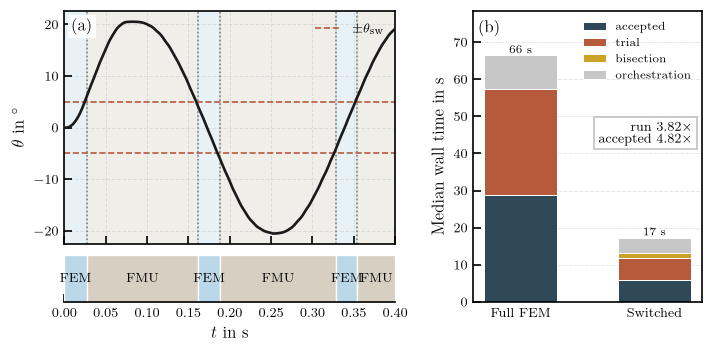

In [16]:
MODE_COLORS = {"FEM": "#bbd8e8", "FMU": "#d6cfc2"}
PHASE_COLORS = {
    ACCEPTED: "#2F4858",
    TRIAL: "#B65A3C",
    BISECTION: "#C9A227",
    EVENTS: "#7B6D8D",
    OTHER: "#9AA5A8",
}
OVERHEAD_COLOR = "0.78"
PANEL_LABEL_STYLE = dict(
    fontweight="bold", fontsize=10,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.95, pad=2),
)

fig = plt.figure(figsize=(FULL_WIDTH, 0.52 * FULL_WIDTH))
outer = fig.add_gridspec(1, 2, width_ratios=[1.45, 1.0], wspace=0.28,
                         left=0.08, right=0.98, top=0.92, bottom=0.13)
left_grid = outer[0, 0].subgridspec(2, 1, height_ratios=[5, 1], hspace=0.08)
ax_traj = fig.add_subplot(left_grid[0, 0])
ax_mode = fig.add_subplot(left_grid[1, 0], sharex=ax_traj)
ax_bar = fig.add_subplot(outer[0, 1])

# --- (a) trajectory with mode shading ---------------------------------------
for left, right, mode in intervals:
    ax_traj.axvspan(left, right, color=MODE_COLORS[mode], alpha=0.35, zorder=0)
ax_traj.plot(switched["t"], switched["theta_deg"], color="#1a1a1a", lw=1.6, zorder=3)
for sign in (+1, -1):
    ax_traj.axhline(sign * THETA_SWITCH_DEG, color="#B65A3C", ls="--", lw=1.0,
                    label=r"$\pm\theta_\mathrm{sw}$" if sign > 0 else None)
for event in switched["sync_events"]:
    ax_traj.axvline(float(event["time"]), color="0.45", ls=":", lw=0.9, zorder=2)
ax_traj.set_ylabel(r"$\theta$ in $^\circ$")
ax_traj.set_xlim(T0, T_END)
ax_traj.grid(True, alpha=0.4)
ax_traj.tick_params(axis="x", labelbottom=False)
ax_traj.legend(loc="upper right", fontsize=8, frameon=False)

for left, right, mode in intervals:
    width = right - left
    if width <= 0:
        continue
    ax_mode.broken_barh([(left, width)], (0, 1), facecolors=MODE_COLORS[mode],
                        edgecolors="white", linewidth=0.8)
    if width / sim_time > 0.06:
        ax_mode.text(left + width / 2, 0.5, mode, ha="center", va="center", fontsize=8)
ax_mode.set_ylim(0, 1)
ax_mode.set_yticks([])
ax_mode.set_xlim(T0, T_END)
ax_mode.set_xlabel(r"$t$ in $\mathrm{s}$")
ax_mode.grid(False)
for spine in ("left", "right", "top"):
    ax_mode.spines[spine].set_visible(False)

# --- (b) stacked wall time ---------------------------------------------------
cases = list(summary.index)
x = np.arange(len(cases))
bottom = np.zeros(len(cases))

for phase in PHASES:
    values = np.array([
        float(df_eval.loc[df_eval["case"] == case, f"solve_{phase}_s"].median())
        for case in cases
    ])
    if not np.any(values > 0):
        continue
    ax_bar.bar(x, values, bottom=bottom, width=0.55, color=PHASE_COLORS[phase],
               label=phase, edgecolor="white", linewidth=0.6)
    bottom += values

overhead = np.array([float(summary.loc[case, "overhead_s"]) for case in cases])
ax_bar.bar(x, overhead, bottom=bottom, width=0.55, color=OVERHEAD_COLOR,
           label="orchestration", edgecolor="white", linewidth=0.6)
bottom += overhead

for xi, total in zip(x, bottom):
    ax_bar.text(xi, total, f"{total:.0f} s", ha="center", va="bottom", fontsize=7)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels([c.replace(" FEM/FMU", "") for c in cases], fontsize=8)
ax_bar.set_ylabel(r"Median wall time in $\mathrm{s}$")
ax_bar.set_ylim(0, bottom.max() * 1.18)
ax_bar.grid(True, axis="y", alpha=0.4)
ax_bar.legend(loc="upper right", fontsize=7, frameon=False)

run_speedup = summary.loc["Switched FEM/FMU", "run_speedup"]
accepted_speedup = summary.loc["Switched FEM/FMU", "accepted_speedup"]
ax_bar.text(
    0.96, 0.62,
    f"run ${run_speedup:.2f}" + r"\times$" + "\n"
    + f"accepted ${accepted_speedup:.2f}" + r"\times$",
    transform=ax_bar.transAxes, ha="right", va="top", fontsize=8,
    bbox=dict(facecolor="white", edgecolor="0.75", alpha=0.95, pad=2.5),
)

for label, ax in [("(a)", ax_traj), ("(b)", ax_bar)]:
    ax.text(0.02, 0.97, label, transform=ax.transAxes, ha="left", va="top", **PANEL_LABEL_STYLE)

fig.savefig(OUT_DIR / "07_performance_nocontact.pdf", bbox_inches="tight")
plt.show()

## Reading the result

Read the tables above rather than any number written into this prose - they are regenerated on every
execution, and absolute timings move with interpreter and machine state.

**Is the wrapper the bottleneck?** Compare `overhead_s` against `solve_s` in the summary, and
`delegation_s` against `overhead_s`. `delegation_s` is the part of orchestration that exists only
because two models are wrapped in one component: each call the algorithm makes on the wrapper
delegates through `active_comp.do_step()`, which adds `_update_output_states()` and conditional
history recording on top of the solve.

**How much model time is thrown away?** The phase table answers this directly, and the `discarded`
line under it aggregates it. Two mechanisms produce it:

1. **Trial steps.** `_detect_crossings` advances every event source across the macro step, evaluates
   the indicators, and restores the snapshot. If no crossing is found, Gauss-Seidel then steps the
   same interval again. On an event-free macro step the model is solved twice for one result. This
   is why the switched case can show `calls_trial` close to `calls_accepted`.
2. **Bisection.** Each located event costs about $\log_2(\Delta t / \mathtt{tol\_time})$ further
   evaluations. `EVENT_TOL_TIME` trades placement precision against that count; at $\Delta t =
   10^{-3}$ and `tol_time` $= 10^{-5}$ that is roughly 7 evaluations per switch, against 17 at the
   default $10^{-8}$.

Both cases run the hybrid algorithm and therefore both carry trial rows, which is what makes
`run_speedup` a like-for-like number here. `accepted_speedup` remains useful as the separate
question of how much of the kept work the model switch removes. The baseline's bisection row stays
empty because its indicator is constant and never brackets a crossing.

For a component that already resolves its own events internally - such as `FEMPendulum` *with*
contact, which reduces its sub-step near the wall and calls `report_internal_event` - bisection is
avoidable entirely. `_locate_event_time` accepts the reported interval directly when it is already
narrower than `tol_time`. That shortcut only fires if `tol_time` is at least as coarse as the
component's internal sub-step. This notebook runs without contact, so the shortcut never applies
here; `06_casestudy_performance.ipynb` is where it matters.

To attribute the remaining orchestration cost, profile rather than adding more manual timers:

```python
import cProfile, pstats
system, plant, models = build_switched_case()
cProfile.run("system.run(T0, T_END, MACRO_DT)", "perf.prof")
pstats.Stats("perf.prof").sort_stats("cumulative").print_stats(25)
```